# 02 - Exploratory Data Analysis
Where do settlement failures concentrate? We look at failure rates across time, channels, amounts and behaviour signals to find the patterns the model should capture.

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({'figure.figsize': (10, 4.5), 'axes.grid': True,
                   'grid.alpha': 0.3, 'font.size': 11})
df = pd.read_csv('../data/raw/transactions.csv', parse_dates=['timestamp'])
df['is_failed'] = (df['status'] == 'failed').astype(int)
df['month'] = df['timestamp'].dt.to_period('M').astype(str)
df['hour'] = df['timestamp'].dt.hour
print(f"{len(df):,} rows | overall failure rate: {df['is_failed'].mean():.2%}")

180,600 rows | overall failure rate: 6.08%


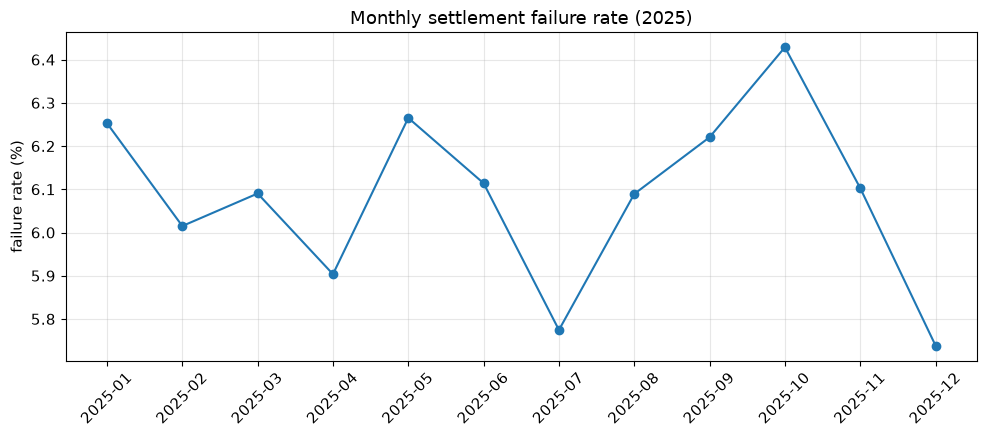

month
2025-01    0.0625
2025-02    0.0601
2025-03    0.0609
2025-04    0.0590
2025-05    0.0627
2025-06    0.0611
2025-07    0.0577
2025-08    0.0609
2025-09    0.0622
2025-10    0.0643
2025-11    0.0610
2025-12    0.0574
Name: mean, dtype: float64

In [2]:
# --- monthly failure trend ---
monthly = df.groupby('month')['is_failed'].agg(['mean','count'])
fig, ax = plt.subplots()
ax.plot(monthly.index, monthly['mean']*100, marker='o')
ax.set_title('Monthly settlement failure rate (2025)')
ax.set_ylabel('failure rate (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
monthly['mean'].round(4)

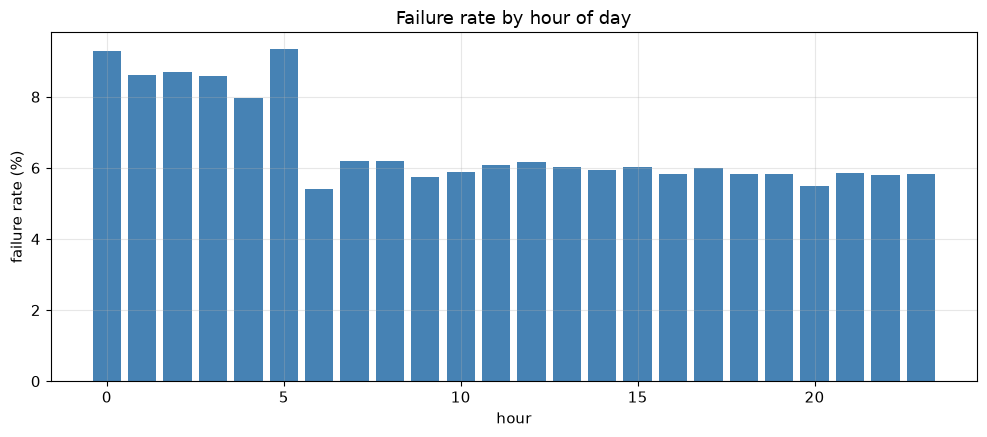

peak hour: 5 (9.35%)
night (0-5) vs rest: 8.90% vs 5.92%


In [3]:
# --- failure rate by hour of day ---
hourly = df.groupby('hour')['is_failed'].mean()*100
fig, ax = plt.subplots()
ax.bar(hourly.index, hourly.values, color='steelblue')
ax.set_title('Failure rate by hour of day')
ax.set_xlabel('hour')
ax.set_ylabel('failure rate (%)')
plt.tight_layout()
plt.show()
print('peak hour:', hourly.idxmax(), f"({hourly.max():.2f}%)")
print('night (0-5) vs rest:',
      f"{df[df['hour'].between(0,5)]['is_failed'].mean():.2%} vs "
      f"{df[~df['hour'].between(0,5)]['is_failed'].mean():.2%}")

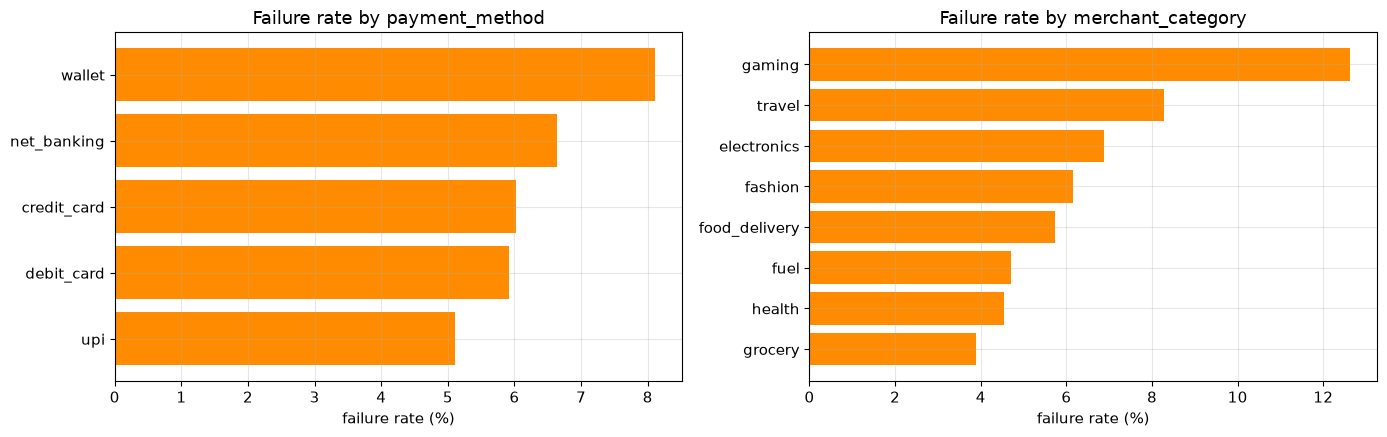

In [4]:
# --- failure rate by payment method and merchant category ---
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
for ax, col in zip(axes, ['payment_method','merchant_category']):
    g = df.groupby(col)['is_failed'].mean().sort_values()*100
    ax.barh(g.index, g.values, color='darkorange')
    ax.set_title(f'Failure rate by {col}')
    ax.set_xlabel('failure rate (%)')
plt.tight_layout()
plt.show()

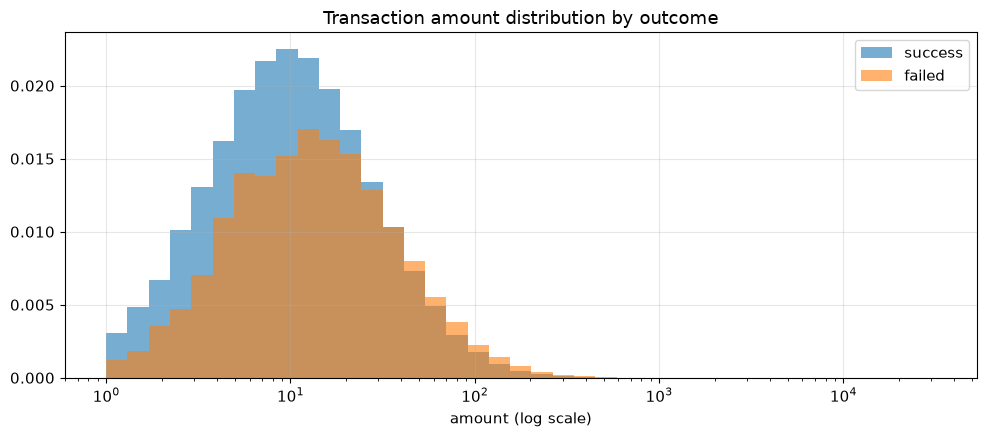

is_failed
0    29.48
1    38.94
Name: transaction_amount, dtype: float64


In [5]:
# --- amount distribution: failed vs successful (log scale) ---
fig, ax = plt.subplots()
bins = np.logspace(0, 4.5, 40)
ax.hist(df.loc[df['is_failed']==0,'transaction_amount'].dropna(), bins=bins,
        alpha=0.6, label='success', density=True)
ax.hist(df.loc[df['is_failed']==1,'transaction_amount'].dropna(), bins=bins,
        alpha=0.6, label='failed', density=True)
ax.set_xscale('log')
ax.set_title('Transaction amount distribution by outcome')
ax.set_xlabel('amount (log scale)')
ax.legend()
plt.tight_layout()
plt.show()
print(df.groupby('is_failed')['transaction_amount'].median().round(2))

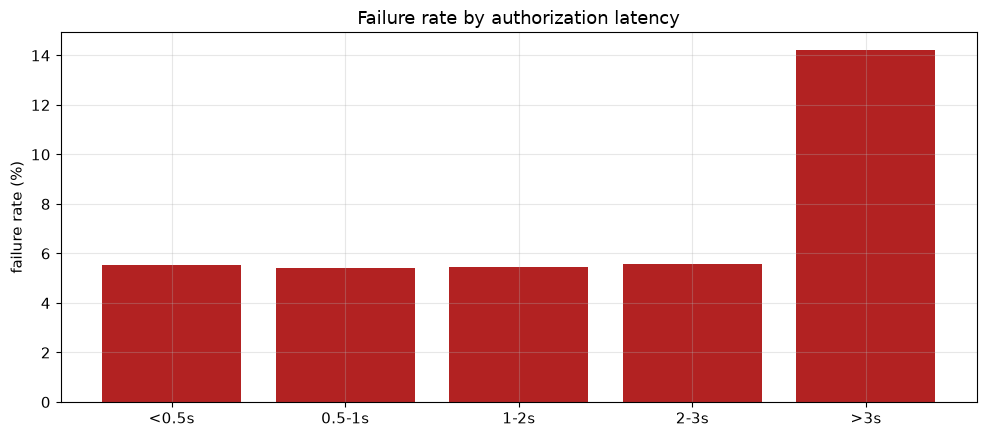

auth_bin
<0.5s      5.52
0.5-1s     5.41
1-2s       5.46
2-3s       5.59
>3s       14.22
Name: is_failed, dtype: float64

In [6]:
# --- authorization latency vs failure ---
df['auth_bin'] = pd.cut(df['authorization_response_time_ms'],
                       bins=[0,500,1000,2000,3000,10000],
                       labels=['<0.5s','0.5-1s','1-2s','2-3s','>3s'])
g = df.groupby('auth_bin', observed=True)['is_failed'].mean()*100
fig, ax = plt.subplots()
ax.bar(g.index.astype(str), g.values, color='firebrick')
ax.set_title('Failure rate by authorization latency')
ax.set_ylabel('failure rate (%)')
plt.tight_layout()
plt.show()
g.round(2)

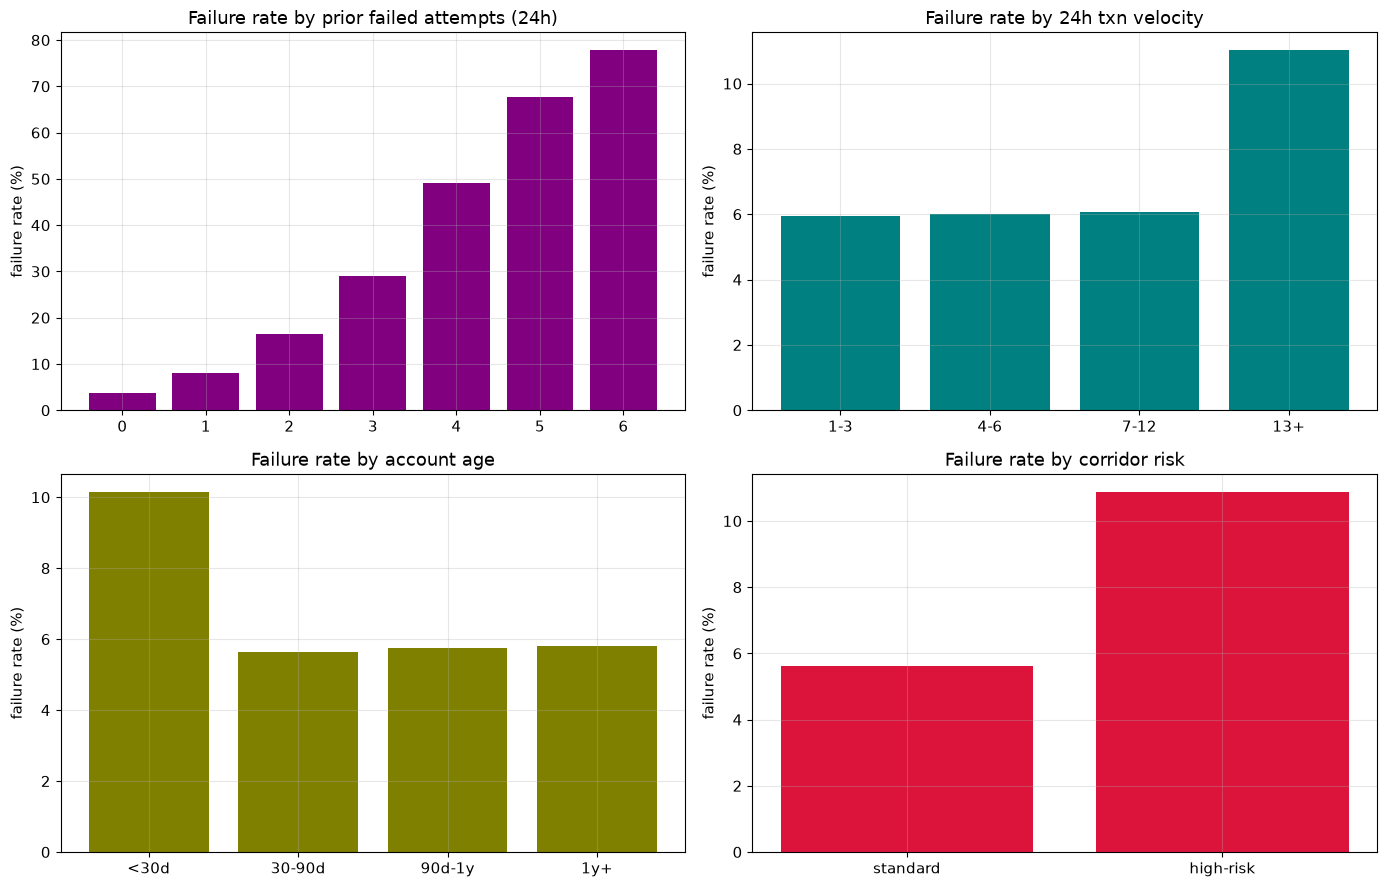

In [7]:
# --- behaviour signals: prior failures, velocity, account age, corridor ---
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
g1 = df.groupby('prior_failed_attempts_24h')['is_failed'].mean()*100
axes[0,0].bar(g1.index.astype(str), g1.values, color='purple')
axes[0,0].set_title('Failure rate by prior failed attempts (24h)')
df['vel_bin'] = pd.cut(df['txn_velocity_24h'], bins=[0,3,6,12,100],
                      labels=['1-3','4-6','7-12','13+'])
g2 = df.groupby('vel_bin', observed=True)['is_failed'].mean()*100
axes[0,1].bar(g2.index.astype(str), g2.values, color='teal')
axes[0,1].set_title('Failure rate by 24h txn velocity')
df['age_bin'] = pd.cut(df['account_age_days'], bins=[0,30,90,365,3001],
                       labels=['<30d','30-90d','90d-1y','1y+'])
g3 = df.groupby('age_bin', observed=True)['is_failed'].mean()*100
axes[1,0].bar(g3.index.astype(str), g3.values, color='olive')
axes[1,0].set_title('Failure rate by account age')
g4 = df.groupby('is_high_risk_country')['is_failed'].mean()*100
axes[1,1].bar(['standard','high-risk'], g4.values, color='crimson')
axes[1,1].set_title('Failure rate by corridor risk')
for ax in axes.flat:
    ax.set_ylabel('failure rate (%)')
plt.tight_layout()
plt.show()

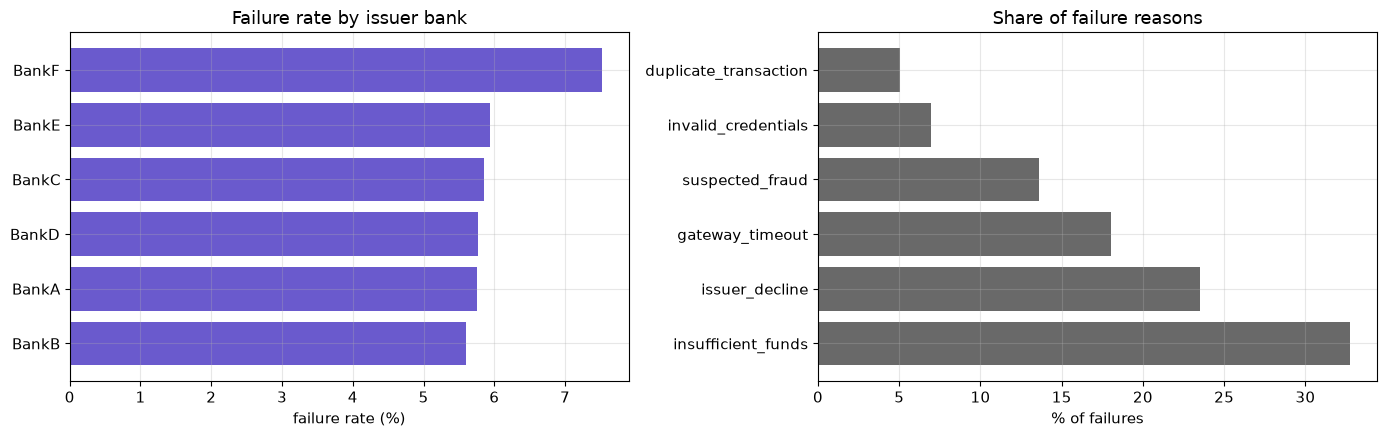

In [8]:
# --- issuer comparison + failure reasons ---
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
g = df.groupby('issuer_bank')['is_failed'].mean().sort_values()*100
axes[0].barh(g.index, g.values, color='slateblue')
axes[0].set_title('Failure rate by issuer bank')
axes[0].set_xlabel('failure rate (%)')
r = df.loc[df['is_failed']==1,'failure_reason'].value_counts(normalize=True)*100
axes[1].barh(r.index, r.values, color='dimgray')
axes[1].set_title('Share of failure reasons')
axes[1].set_xlabel('% of failures')
plt.tight_layout()
plt.show()

## EDA takeaways
- Failures are **not uniform**: night hours, slow authorizations (>3s), high-velocity bursts, brand-new accounts and high-risk corridors all show clearly elevated failure rates.
- Behavioural signals dominate: prior failed attempts in the last 24h is the single strongest separator, followed by authorization latency.
- Channel mix matters: wallets and gaming merchants fail more often; UPI and grocery fail less.
- One issuer (visible in the chart above) declines more than peers - a useful categorical feature.
- `failure_reason` describes the outcome, so it must stay **out** of the model (leakage).
- Next: **03_model_training** - clean, engineer features, train and compare the two models.